# 00 — Auditoria do banco sociodemográfico

## 1. Objetivo

Determinar se o banco bruto está consistente e adequado para análise, sem alterar qualquer dado. A auditoria identifica a amostra real, completude, duplicatas, tipos, problemas de formato e possíveis valores implausíveis.

**Privacidade:** valores da coluna de identificação nominal nunca são exibidos. `df.head()` e `df.tail()` são executados com a saída deliberadamente suprimida.

## 2. Importações

In [1]:
from io import StringIO
from pathlib import Path
import platform
import re
import sys
import unicodedata

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

## 3. Configuração

In [2]:
RANDOM_STATE = 42
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data" / "raw" / "sociodemografico.csv").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.plots import plot_missing_data, save_figure

RAW_PATH = PROJECT_ROOT / "data" / "raw" / "sociodemografico.csv"
TABLES_DIR = PROJECT_ROOT / "outputs" / "tables"
MISSING_FIGURE_PATH = PROJECT_ROOT / "outputs" / "figures" / "missing_data.png"
QUALITY_PATH = TABLES_DIR / "data_quality_report.csv"
MISSING_PATH = TABLES_DIR / "missing_data.csv"
NAME_COLUMN = "nome"

assert RAW_PATH.exists(), f"CSV bruto não encontrado: {RAW_PATH}"
print(f"Python: {platform.python_version()}")
print(f"pandas: {pd.__version__}")
print(f"numpy: {np.__version__}")
print(f"matplotlib: {matplotlib.__version__}")

Python: 3.14.6
pandas: 3.0.5
numpy: 2.5.2
matplotlib: 3.11.1


## 4. Carregamento

O CSV é apenas lido. Nenhuma escrita é feita em `data/raw/`.

In [3]:
df = pd.read_csv(RAW_PATH)

# Operações obrigatórias da auditoria. As duas amostras não são exibidas por privacidade.
raw_shape = df.shape
info_buffer = StringIO()
df.info(buf=info_buffer)
df.head();
df.tail();
raw_missing = df.isna().sum()
raw_nunique = df.nunique(dropna=True)
raw_duplicates = int(df.duplicated().sum())

print(f"Dimensão bruta (df.shape): {raw_shape[0]} linhas × {raw_shape[1]} colunas")
print(info_buffer.getvalue())
print("df.head() e df.tail() executados; saída suprimida para proteger a identidade dos pacientes.")
display(pd.DataFrame({
    "tipo_inferido": df.dtypes.astype(str),
    "n_missing_bruto": raw_missing,
    "n_unicos_bruto": raw_nunique,
}).rename_axis("variavel"))
print(f"Duplicatas exatas no arquivo bruto (df.duplicated().sum()): {raw_duplicates}")

Dimensão bruta (df.shape): 100 linhas × 32 colunas
<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 32 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   Cod                                      100 non-null    int64  
 1   nome                                     75 non-null     str    
 2   estado civil                             75 non-null     str    
 3   escolaridade                             75 non-null     str    
 4   ocupação                                 75 non-null     str    
 5   renda mensal familiar                    75 non-null     str    
 6   diagnóstico principal                    75 non-null     str    
 7   tempo de diagnóstico                     73 non-null     str    
 8   usa ou usou corticoide recente?          100 non-null    bool   
 9   faz uso de medicamento imunobiologico?   63 non-null     str    
 10  tempo de me

,tipo_inferido,n_missing_bruto,n_unicos_bruto
variavel,,,
Cod,int64,0,100
nome,str,25,75
estado civil,str,25,4
escolaridade,str,25,7
ocupação,str,25,44
renda mensal familiar,str,25,4
diagnóstico principal,str,25,15
tempo de diagnóstico,str,27,56
usa ou usou corticoide recente?,bool,0,2


Duplicatas exatas no arquivo bruto (df.duplicated().sum()): 0


## 5. Validações

A presença de nome preenchido, após ignorar espaços, define programaticamente um paciente válido. O nome é usado somente para essa máscara e para verificar duplicidade; seus valores nunca são exibidos ou exportados.

In [4]:
def is_present(series):
    text = series.astype("string")
    return text.notna() & text.str.strip().ne("")

assert NAME_COLUMN in df.columns
valid_patient_mask = is_present(df[NAME_COLUMN])
valid_df = df.loc[valid_patient_mask].copy()
all_present = df.apply(is_present)

n_raw = len(df)
n_valid = int(valid_patient_mask.sum())
n_without_patient = int((~valid_patient_mask).sum())
n_literal_empty = int((~all_present.any(axis=1)).sum())
clinical_columns = [column for column in df.columns if column not in {
    "Cod", NAME_COLUMN, "usa ou usou corticoide recente?"
}]
n_without_patient_with_clinical_data = int(
    ((~valid_patient_mask) & all_present[clinical_columns].any(axis=1)).sum()
)

normalized_names = (
    valid_df[NAME_COLUMN].astype("string").str.strip().str.casefold()
)
normalized_codes = (
    valid_df["Cod"].astype("string").str.strip().str.casefold()
)
n_valid_exact_duplicates = int(valid_df.duplicated().sum())
n_duplicate_names = int(normalized_names.duplicated().sum())
n_duplicate_codes = int(normalized_codes.duplicated().sum())

sample_summary = pd.DataFrame({
    "metrica": [
        "Linhas do arquivo original",
        "Pacientes válidos",
        "Registros sem paciente",
        "Linhas literalmente vazias",
        "Registros sem paciente com dado clínico",
        "Duplicatas exatas no arquivo bruto",
        "Duplicatas exatas entre pacientes válidos",
        "Identificadores nominais duplicados",
        "Códigos duplicados entre pacientes válidos",
    ],
    "n": [
        n_raw, n_valid, n_without_patient, n_literal_empty,
        n_without_patient_with_clinical_data, raw_duplicates,
        n_valid_exact_duplicates, n_duplicate_names, n_duplicate_codes,
    ],
})
display(sample_summary)

assert n_raw == n_valid + n_without_patient
assert n_without_patient_with_clinical_data == 0, (
    "Há registro sem identificação nominal contendo dado clínico; a regra de elegibilidade exige revisão."
)

,metrica,n
0,Linhas do arquivo original,100
1,Pacientes válidos,75
2,Registros sem paciente,25
3,Linhas literalmente vazias,0
4,Registros sem paciente com dado clínico,0
5,Duplicatas exatas no arquivo bruto,0
6,Duplicatas exatas entre pacientes válidos,0
7,Identificadores nominais duplicados,0
8,Códigos duplicados entre pacientes válidos,0


## 6. Análise de qualidade

Todos os percentuais de ausência abaixo usam como denominador os pacientes válidos, não as 100 linhas brutas. Conversões numéricas são temporárias e servem apenas à auditoria.

In [5]:
def normalize_text(value):
    if pd.isna(value):
        return pd.NA
    normalized = unicodedata.normalize("NFKD", str(value))
    normalized = "".join(char for char in normalized if not unicodedata.combining(char))
    return re.sub(r"\s+", " ", normalized.strip().casefold())

def parse_numeric_for_audit(series, column):
    text = series.astype("string").str.strip()
    if column == "resultado do findrisk":
        text = text.str.extract(r"^\s*([+-]?\d+(?:[.,]\d+)?)", expand=False)
    if column == "hbA1c":
        text = text.str.replace("%", "", regex=False)
    text = text.str.replace(",", ".", regex=False)
    return pd.to_numeric(text, errors="coerce")

numeric_specs = {
    "Cod": (None, None, "inteiro"),
    "circunferência cervical": (20, 70, "float"),
    "CT": (50, 500, "float"),
    "LDL": (10, 400, "float"),
    "HDL": (10, 150, "float"),
    "VRDL": (1, 200, "float"),
    "TG": (20, 1000, "float"),
    "Glicemia": (20, 600, "float"),
    "hbA1c": (2, 20, "float"),
    "Altura": (0.8, 2.3, "float"),
    "Peso": (20, 300, "float"),
    "IMC": (10, 80, "float"),
    "CA": (40, 200, "float"),
    "resultado do findrisk": (0, 26, "inteiro"),
    "resultado BASDAI": (0, 10, "float"),
    "resultado SLICC": (0, None, "float"),
    "resultado DAS-28": (0, 10, "float"),
}

def expected_findrisc_category(score):
    if pd.isna(score):
        return pd.NA
    if score < 7:
        return "baixo risco"
    if score <= 11:
        return "leve/moderado"
    if score <= 14:
        return "moderado"
    if score <= 20:
        return "alto"
    return "muito alto"

findrisc_text = valid_df["resultado do findrisk"].astype("string")
findrisc_scores = parse_numeric_for_audit(findrisc_text, "resultado do findrisk")
findrisc_labels = findrisc_text.str.extract(r"\((.*?)\)", expand=False).map(normalize_text)
findrisc_aliases = {
    "baixo risco": {"baixo risco"},
    "leve/moderado": {"leve/moderado", "leve moderado", "risco levemente elevado"},
    "moderado": {"moderado", "risco moderado"},
    "alto": {"alto", "alto risco", "risco alto"},
    "muito alto": {"muito alto", "muito alto risco", "risco muito alto"},
}
findrisc_expected = findrisc_scores.map(expected_findrisc_category)
findrisc_label_present = findrisc_labels.notna()
findrisc_label_mismatch = pd.Series(False, index=valid_df.index)
for index in valid_df.index[findrisc_label_present]:
    expected = findrisc_expected.loc[index]
    findrisc_label_mismatch.loc[index] = findrisc_labels.loc[index] not in findrisc_aliases[expected]
n_findrisc_labeled = int(findrisc_label_present.sum())
n_findrisc_label_mismatch = int(findrisc_label_mismatch.sum())

missing_rows = []
quality_rows = []
for column in df.columns:
    series = valid_df[column]
    present = is_present(series)
    text = series.astype("string")
    nonmissing_text = text[present]
    n_present = int(present.sum())
    n_missing = n_valid - n_present
    pct_missing = 100 * n_missing / n_valid if n_valid else np.nan
    observations = []

    if column != column.strip():
        observations.append("Cabeçalho contém espaço excedente.")
    if column == NAME_COLUMN:
        observations.append("Identificador protegido; valores nunca exibidos ou exportados.")
    if n_missing == n_valid:
        observations.append("Variável completamente vazia entre pacientes válidos.")
    elif pct_missing >= 20:
        observations.append("Missing relevante (≥20%).")

    whitespace_count = int((nonmissing_text != nonmissing_text.str.strip()).sum())
    if whitespace_count:
        observations.append(f"{whitespace_count} valor(es) com espaço antes/depois.")

    decimal_comma_count = int(nonmissing_text.str.contains(r"\d,\d", regex=True, na=False).sum())
    if decimal_comma_count:
        observations.append(f"{decimal_comma_count} valor(es) com vírgula decimal.")

    stripped = nonmissing_text.str.strip()
    normalized = stripped.map(normalize_text)
    collapsed_variants = int(stripped.nunique() - normalized.nunique())
    if collapsed_variants > 0:
        observations.append(
            f"{collapsed_variants} variante(s) categórica(s) diferem apenas por caixa/espaços/acentuação."
        )

    minimum = np.nan
    maximum = np.nan
    if column in numeric_specs:
        lower, upper, suggested_type = numeric_specs[column]
        numeric = parse_numeric_for_audit(series, column)
        numeric_nonmissing = numeric.dropna()
        if not numeric_nonmissing.empty:
            minimum = float(numeric_nonmissing.min())
            maximum = float(numeric_nonmissing.max())
        conversion_failures = int((present & numeric.isna()).sum())
        if conversion_failures:
            observations.append(f"{conversion_failures} valor(es) não conversível(is) para número na auditoria.")
        if n_present and not pd.api.types.is_numeric_dtype(series.dtype):
            observations.append(f"Variável numérica armazenada como texto; tipo sugerido: {suggested_type}.")
        plausible = numeric.notna()
        if lower is not None:
            plausible &= numeric >= lower
        if upper is not None:
            plausible &= numeric <= upper
        implausible_count = int((numeric.notna() & ~plausible).sum())
        if implausible_count:
            observations.append(
                f"{implausible_count} possível(is) valor(es) biologicamente implausível(is); revisar na limpeza."
            )

    special_notes = {
        "tempo de diagnóstico": "Campo heterogêneo mistura durações, anos e texto livre.",
        "faz uso de medicamento imunobiologico? ": "Campo mistura resposta sim/não e nomes de medicamentos.",
        "VRDL": "Confirmar se o cabeçalho pretendido é VLDL.",
        "PA": "Pressão arterial registrada como texto composto e com alta ausência.",
        "IMC": "Não é possível conferir o cálculo do IMC: Altura e Peso estão 100% ausentes.",
        "comorbidade associada/medicamento": "Campo livre mistura múltiplas condições e medicamentos.",
        "tabagismo": "Campo mistura status atual e histórico de exposição.",
        "etilismo": "Campo mistura status atual, frequência e histórico.",
        "ativ física?": "Campo mistura status, modalidade, frequência e duração.",
        "diagnóstico principal": "Há registros com diagnósticos múltiplos; preservar o original na limpeza.",
    }
    if column in special_notes:
        observations.append(special_notes[column])
    if column == "resultado do findrisk":
        observations.append(
            f"Pontuação extraível em {int(findrisc_scores.notna().sum())} registro(s); "
            f"{n_findrisc_labeled} têm rótulo textual e {n_findrisc_label_mismatch} rótulo(s) divergem da classificação pela pontuação."
        )
        observations.append("Cabeçalho usa 'findrisk'; padronizar posteriormente para FINDRISC.")

    missing_rows.append({
        "variavel": column,
        "n_valido": n_present,
        "n_ausente": n_missing,
        "percentual_ausente": round(pct_missing, 2),
    })
    quality_rows.append({
        "variavel": column,
        "tipo_original": str(df[column].dtype),
        "tipo_final": f"não alterado ({df[column].dtype})",
        "n_valido": n_present,
        "n_missing": n_missing,
        "percentual_missing": round(pct_missing, 2),
        "minimo": minimum,
        "maximo": maximum,
        "n_categorias": int(stripped.nunique()),
        "observacoes": " ".join(observations) or "Nenhuma inconsistência automática identificada.",
    })

missing_data = pd.DataFrame(missing_rows)
data_quality_report = pd.DataFrame(quality_rows)

TABLES_DIR.mkdir(parents=True, exist_ok=True)
missing_data.to_csv(MISSING_PATH, index=False, encoding="utf-8")
data_quality_report.to_csv(QUALITY_PATH, index=False, encoding="utf-8")

display(missing_data)
display(data_quality_report.drop(columns=["tipo_final"]))

,variavel,n_valido,n_ausente,percentual_ausente
0,Cod,75,0,0.00
1,nome,75,0,0.00
2,estado civil,75,0,0.00
3,escolaridade,75,0,0.00
4,ocupação,75,0,0.00
5,renda mensal familiar,75,0,0.00
6,diagnóstico principal,75,0,0.00
7,tempo de diagnóstico,73,2,2.67
8,usa ou usou corticoide recente?,75,0,0.00
9,faz uso de medicamento imunobiologico?,63,12,16.00


,variavel,tipo_original,n_valido,n_missing,percentual_missing,minimo,maximo,n_categorias,observacoes
0,Cod,int64,75,0,0.00,1.0,75.0,75,Nenhuma inconsistência automática identificada.
1,nome,str,75,0,0.00,NaN,NaN,75,Identificador protegido; valores nunca exibido...
2,estado civil,str,75,0,0.00,NaN,NaN,4,Nenhuma inconsistência automática identificada.
3,escolaridade,str,75,0,0.00,NaN,NaN,7,Nenhuma inconsistência automática identificada.
4,ocupação,str,75,0,0.00,NaN,NaN,41,Cabeçalho contém espaço excedente. 12 valor(es...
5,renda mensal familiar,str,75,0,0.00,NaN,NaN,4,Nenhuma inconsistência automática identificada.
6,diagnóstico principal,str,75,0,0.00,NaN,NaN,14,11 valor(es) com espaço antes/depois. Há regis...
7,tempo de diagnóstico,str,73,2,2.67,NaN,NaN,55,1 valor(es) com espaço antes/depois. Campo het...
8,usa ou usou corticoide recente?,bool,75,0,0.00,NaN,NaN,2,Nenhuma inconsistência automática identificada.
9,faz uso de medicamento imunobiologico?,str,63,12,16.00,NaN,NaN,33,Cabeçalho contém espaço excedente. 10 valor(es...


## 7. Visualização

A figura mostra apenas completude por variável e não é exportada neste Goal.

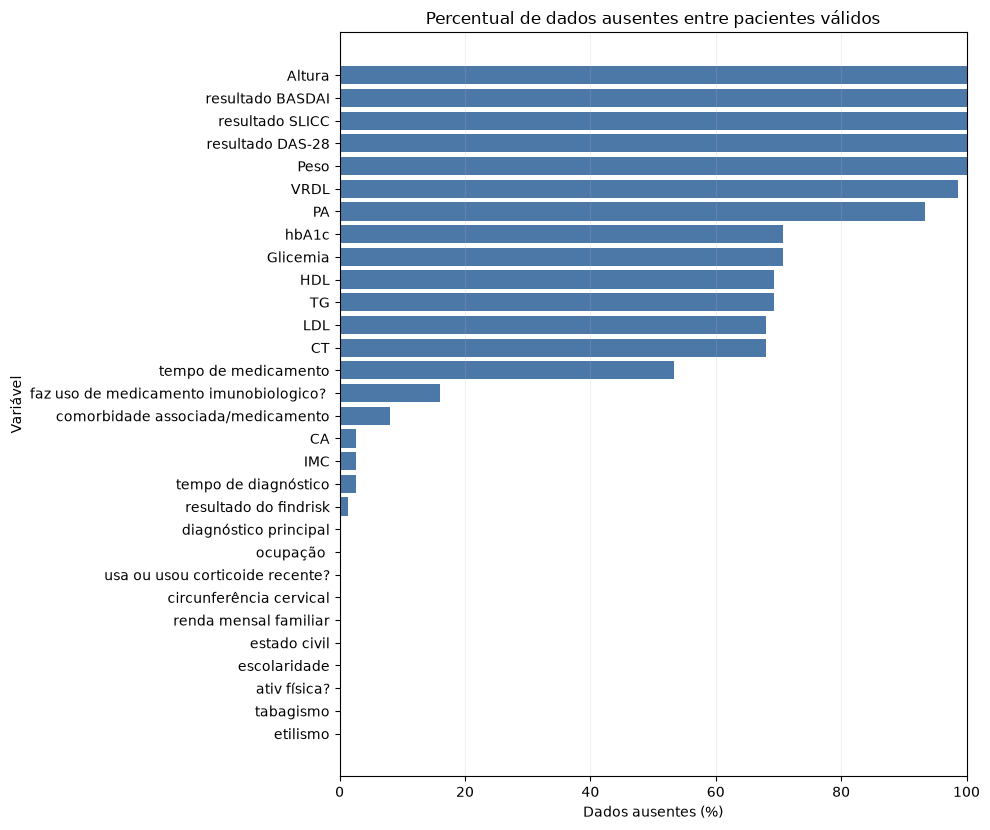

In [6]:
figure, _ = plot_missing_data(missing_data)
save_figure(figure, MISSING_FIGURE_PATH)
plt.show()

## 8. Conclusões da auditoria

In [7]:
fully_missing_variables = missing_data.loc[
    missing_data["percentual_ausente"].eq(100), "variavel"
].tolist()
high_missing_variables = missing_data.loc[
    missing_data["percentual_ausente"].ge(50), "variavel"
].tolist()

print(f"N de linhas do arquivo original: {n_raw}")
print(f"N de pacientes válidos: {n_valid}")
print(f"N de registros vazios/sem paciente: {n_without_patient}")
print(f"N de duplicatas exatas: {raw_duplicates}")
print(f"Variáveis completamente vazias: {len(fully_missing_variables)} ({', '.join(fully_missing_variables)})")
print(f"Variáveis com pelo menos 50% de missing: {len(high_missing_variables)} ({', '.join(high_missing_variables)})")
print("Principais inconsistências:")
print("- 25 linhas sem paciente contêm apenas campos estruturais/padrão e não integram a amostra real.")
print("- Há números armazenados como texto, sobretudo por vírgula decimal e unidades/sufixos.")
print("- Há espaços excedentes em cabeçalhos e valores, além de categorias semanticamente heterogêneas.")
print("- Um valor de circunferência cervical requer conferência por possível implausibilidade biológica.")
print(f"- FINDRISC: {n_findrisc_label_mismatch} rótulo(s) textual(is) divergem da categoria definida pela pontuação.")
print("- O IMC registrado não pode ser recalculado neste banco porque Altura e Peso estão completamente ausentes.")
print("Nenhum dado foi corrigido, imputado, excluído ou gravado sobre o CSV bruto.")

N de linhas do arquivo original: 100
N de pacientes válidos: 75
N de registros vazios/sem paciente: 25
N de duplicatas exatas: 0
Variáveis completamente vazias: 5 (Altura, Peso, resultado BASDAI, resultado SLICC, resultado DAS-28)
Variáveis com pelo menos 50% de missing: 14 (tempo de medicamento, CT, LDL, HDL, VRDL, TG, Glicemia, hbA1c, PA, Altura, Peso, resultado BASDAI, resultado SLICC, resultado DAS-28)
Principais inconsistências:
- 25 linhas sem paciente contêm apenas campos estruturais/padrão e não integram a amostra real.
- Há números armazenados como texto, sobretudo por vírgula decimal e unidades/sufixos.
- Há espaços excedentes em cabeçalhos e valores, além de categorias semanticamente heterogêneas.
- Um valor de circunferência cervical requer conferência por possível implausibilidade biológica.
- FINDRISC: 3 rótulo(s) textual(is) divergem da categoria definida pela pontuação.
- O IMC registrado não pode ser recalculado neste banco porque Altura e Peso estão completamente ause

## 9. Outputs gerados

In [8]:
for output_path in (QUALITY_PATH, MISSING_PATH):
    assert output_path.exists() and output_path.stat().st_size > 0
    print(output_path.relative_to(PROJECT_ROOT))

outputs/tables/data_quality_report.csv
outputs/tables/missing_data.csv
